# Reduced turbine characteristic

The data and correlations used for the reduced turbine characteristics are
derived from the ORC turbo design workshop. Due to time constraints we go
beyond the original simplification and will assume that the turbine 
characteristics for isentropic efficiency and mass flow are scalable.
Therefore, we normalize the correlations to their design point and will 
apply the change in isentropic efficiency and the change in mass flow with
respect to the design point. The actual design point of the modeled cycle would
then correspond to an area and a pressure ratio that might be very different
from the original data.

Implement the following correlations into the TESPy model:

$$\frac{\eta_{is}}{\eta_{is,d}} = f\!\left(\frac{\Pi}{\Pi_d}\right), \qquad
\frac{\dot m}{\dot m_d} = g\!\left(\frac{p_{in}}{p_{in,d}}\right)$$

Source of data: 

Jan Spale et al. (2026): "Design methodology and experimental
assessment of a small-scale supersonic axial impulse ORC turbine",
https://doi.org/10.1016/j.energy.2026.141901.

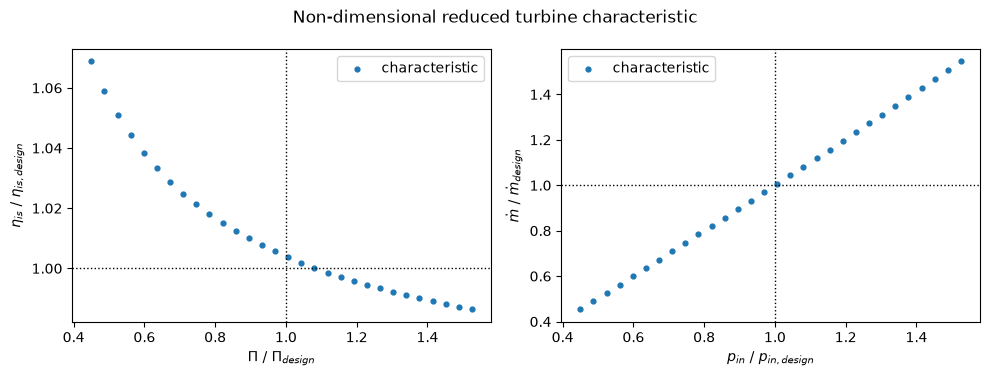

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np


with open("turbine_reduced_characteristic.json") as f:
    CHAR = json.load(f)

PI_DATA = np.array(CHAR["characteristic"]["pressure_ratio"])
ETA_DATA = np.array(CHAR["characteristic"]["eta_is_ts"])
P_DATA = np.array(CHAR["characteristic"]["p_in_Pa"])
M_DATA = np.array(CHAR["characteristic"]["m_dot_kg_s"])

PI_D_CHAR = CHAR["design_point"]["pressure_ratio"]
P_D_CHAR = CHAR["design_point"]["p_in_Pa"]

ETA_S_D = CHAR["design_point"]["eta_is_ts"]
M_D = CHAR["design_point"]["m_dot_kg_s"]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
x = np.linspace(PI_DATA[0] / PI_D_CHAR, PI_DATA[-1] / PI_D_CHAR, 200)
ax1.scatter(
    PI_DATA / PI_D_CHAR, ETA_DATA / ETA_S_D,
    s=12, label="characteristic"
)
ax1.set_xlabel("$\\Pi$ / $\\Pi_{design}$")
ax1.set_ylabel("$\\eta_{is}$ / $\\eta_{is,design}$")
ax1.legend()
y = np.linspace(P_DATA[0] / P_D_CHAR, P_DATA[-1] / P_D_CHAR, 200)
ax2.scatter(
    P_DATA / P_D_CHAR, M_DATA / M_D,
    s=12, label="characteristic"
)
ax2.set_xlabel("$p_{in}$ / $p_{in,design}$")
ax2.set_ylabel("$\\dot m$ / $\\dot m_{design}$")
ax2.legend()
for ax in (ax1, ax2):
    ax.axvline(1, color="k", ls=":", lw=1)
    ax.axhline(1, color="k", ls=":", lw=1)
fig.suptitle("Non-dimensional reduced turbine characteristic")
fig.tight_layout()
plt.show()
